<a href="https://colab.research.google.com/github/lelyashashlyk/DataScienceLearning/blob/main/pandas/df_fillna_duplicates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INTRO


### Работа с пропущенными значениями в Data Science: за пределами `dropna()` и `fillna()`

В реальных задачах пропущенные значения (**missing values**) — это скорее норма, чем исключение. Они могут появляться по множеству причин: ошибки ввода, неполные анкеты, сбои в логировании, особенности поведения пользователей. И прежде чем строить модель, нужно **осознанно подойти к их обработке**, потому что способ, которым вы заполняете или удаляете пропуски, напрямую влияет на результаты анализа и качество моделей машинного обучения.

---

## ❓ Почему пропущенные значения — это важно

Пропущенные данные — это **не просто пустоты**. Часто они **содержат смысл**. Примеры:

- Пропущенное значение дохода может означать «не захотел указывать».
- Пропущенное время транзакции — возможно, транзакция не была завершена.
- Отсутствие рейтинга — пользователь не взаимодействовал с продуктом.

Слепое применение `dropna()` или `fillna()` может **уничтожить полезную информацию** или **исказить распределение** признаков.

---

## 🧹 Базовые методы

### `dropna()`

Удаляет строки с пропущенными значениями. Простой и часто применяемый метод.

**Плюсы:**
- Удаляет "грязные" данные.
- Не вносит предположений.

**Минусы:**
- Потеря информации.
- Потенциальный **sampling bias** — если данные не случайно пропущены (not **Missing Completely at Random**, MCAR).

---

### `fillna()` с фиксированными значениями

Часто заполняют:

- Нулями: `df['feature'].fillna(0)`
- Средним: `df['feature'].fillna(df['feature'].mean())`
- Медианой: `fillna(df['feature'].median())`
- Модой (для категориальных): `fillna(df['feature'].mode()[0])`

**Что может пойти не так?**

- **Искажение распределения**: заполнение средним делает его "островом стабильности", в реальности редко встречающимся.
- **Смазывание зависимости**: может "сгладить" корреляции.
- **Изменение дисперсии**: особенно опасно при `fillna(0)`.

---

## 🎯 Более продвинутые стратегии

### Заполнение по группам (`groupby`-based imputation)

Вместо глобального среднего можно заполнять, например, средним **в пределах категории**:

```python
df['income'] = df.groupby('region')['income'].transform(
    lambda x: x.fillna(x.mean())
)
```

**Преимущество**: сохраняется **внутригрупповая структура**, распределение менее искажается.

---

### Заполнение с помощью модели (ML-based imputation)

Если признак `feature_A` пропущен, можно обучить модель предсказания `feature_A` на остальных признаках (`feature_B`, `feature_C`, ...) и заполнить значения **предсказаниями**.

- Простые модели: `LinearRegression`, `KNNImputer`, `RandomForestRegressor`.
- Готовые пайплайны: `IterativeImputer` из `sklearn.impute`.

```python
from sklearn.impute import IterativeImputer
imp = IterativeImputer()
df_imputed = imp.fit_transform(df)
```

**Плюсы:**
- Учитывает взаимосвязи между признаками.
- Потенциально более точные оценки.

**Минусы:**
- Дольше по времени.
- Риск **data leakage**, если неправильно организовать пайплайн.

---

### Создание индикаторов пропуска (missing indicators)

Добавляется бинарный признак: был ли пропуск в этом поле.

```python
df['feature_is_null'] = df['feature'].isnull().astype(int)
```

Полезно, когда **факт пропуска сам по себе информативен**.

---

## 📌 Резюме: Не все пропуски равны

Перед тем как заполнять или удалять:

1. Пойми, **почему** значение пропущено. Это **MCAR**, **MAR** или **MNAR**?
2. Оцени, как повлияет заполнение на **распределение** и **взаимосвязи**.
3. Подумай о **сохранении информации**: не всё нужно заполнять, иногда пропуск — это важный сигнал.

---

## 🚀 Впереди

Давайте посмотрим все это на практике! GO.....

# Theoretical part

Сгенерим датафрейм для изучения функций:


*   `as_type()`

*   `fillna()`

*   `dropna()`
*   `duplicated()`


*   `drop_duplicates()`






## Создадим датасет

Датасет будет состоять из 1500 строк:

In [114]:
N_ROWS = 1500

In [115]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Создадим три количественные фичи датафрейма. Также в некоторые колонки искусственно добавим пропуски с указанным процентом. Нам понадобятся следующие функции:

* `np.random.randint(from, to, num)` - функция, которая создает последовательность случайных числел в указанном первыми двумя аргументами диапазоне в указанном третьим аргументом количестве. Распределение равномерное!
* `np.random.randn(shape)` - создает массив данных указанной формы (многомерный массив или вектор) со стандартизированным Гаусовым распределением.
* `np.random.choice(array, size, p=list)` - позволяет выбрать из массива `array` или списка значения случайным образом в указанном количестве аргументом `size`. Также для каждого элемента можно указать вероятность появления значения аргументом `p`. В нашем примере мы так будем создавать бинарный массив.

In [116]:
col_1 = np.random.randint(1, 20, N_ROWS).astype(str)
col_2 = np.random.randint(10, 100, N_ROWS)
col_3 = np.random.randn(N_ROWS)*5
null_mask_1 = np.random.choice([0, 1], size=N_ROWS, p=[0.8, 0.2]).astype(bool) # маски для замены значения пропуском
null_mask_2 = np.random.choice([0, 1], size=N_ROWS, p=[0.2, 0.8]).astype(bool)
null_mask_3 = np.random.choice([0, 1], size=N_ROWS, p=[0.6, 0.4]).astype(bool)

In [117]:
df = pd.DataFrame({'A':col_1,
                   'B':col_2,
                   'C':col_3})
df.loc[null_mask_1, 'A'] = np.nan
df.loc[null_mask_2, 'B'] = np.nan
df.loc[null_mask_3, 'C'] = np.nan

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       1208 non-null   object 
 1   B       306 non-null    float64
 2   C       901 non-null    float64
dtypes: float64(2), object(1)
memory usage: 35.3+ KB


Coздадим одну категориальную (номинативную) фичу с уникальными значениями `foo`, `bar`, `baz`. Так мы создадим в данных три группы.

In [118]:
cat = ['foo', 'bar', 'baz']
cat_feature = np.random.choice(cat, size=N_ROWS, p=[0.3, 0.3, 0.4])
df['D'] = cat_feature

<Axes: xlabel='count', ylabel='D'>

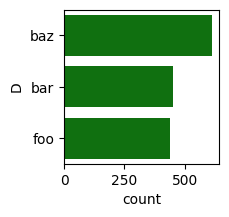

In [119]:
plt.subplots(figsize=(2, 2))
sns.barplot(x=df.value_counts('D'), y=df.value_counts('D').index, color='green')

Подчеркнем различия по группам для колонки `C`:
* значения для `bar` увеличим на 10
* значения для `baz` уменьшим на 15

In [120]:
df.loc[df.D == 'bar', 'C'] += 10
df.loc[df.D == 'baz', 'C'] += -15

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       1208 non-null   object 
 1   B       306 non-null    float64
 2   C       901 non-null    float64
 3   D       1500 non-null   object 
dtypes: float64(2), object(2)
memory usage: 47.0+ KB


In [122]:
df.dtypes

,0
A,object
B,float64
C,float64
D,object


In [123]:
df.head()

,A,B,C,D
0,18,NaN,NaN,foo
1,17,NaN,NaN,bar
2,18,NaN,NaN,foo
3,14,NaN,NaN,baz
4,NaN,NaN,NaN,bar


Оформим весь этот код как функцию:

In [124]:
def get_data(N_ROWS:int)->pd.DataFrame:
  col_1 = np.random.randint(1, 20, N_ROWS).astype(str)
  col_2 = np.random.randint(10, 100, N_ROWS)
  col_3 = np.random.randn(N_ROWS)*5
  null_mask_1 = np.random.choice([0, 1], size=N_ROWS, p=[0.8, 0.2]).astype(bool) # маски для замены значения пропуском
  null_mask_2 = np.random.choice([0, 1], size=N_ROWS, p=[0.2, 0.8]).astype(bool)
  null_mask_3 = np.random.choice([0, 1], size=N_ROWS, p=[0.6, 0.4]).astype(bool)
  df = pd.DataFrame({'A':col_1,
                    'B':col_2,
                    'C':col_3})
  df.loc[null_mask_1, 'A'] = np.nan
  df.loc[null_mask_2, 'B'] = np.nan
  df.loc[null_mask_3, 'C'] = np.nan
  cat = ['foo', 'bar', 'baz']
  cat_feature = np.random.choice(cat, size=N_ROWS, p=[0.3, 0.3, 0.4])
  df['D'] = cat_feature
  df.loc[df.D == 'bar', 'C'] += 10
  df.loc[df.D == 'baz', 'C'] += -15
  return df

# Заполнение пропусков
`fillna()` - заполняет пропуски указанным значением.

## Заполнение пропусков в колонке `A`

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       1208 non-null   object 
 1   B       306 non-null    float64
 2   C       901 non-null    float64
 3   D       1500 non-null   object 
dtypes: float64(2), object(2)
memory usage: 47.0+ KB


In [126]:
df.head(3)

,A,B,C,D
0,18,NaN,NaN,foo
1,17,NaN,NaN,bar
2,18,NaN,NaN,foo


In [129]:
df.A.astype(int)

ValueError: cannot convert float NaN to integer

In [130]:
df.A.fillna(0)

,A
0,18
1,17
2,18
3,14
4,0
...,...
1495,6
1496,12
1497,17
1498,17


Заполнит пропуски нулем, однако тип данных не изменится.
Более адекватно будет заполнить пропуски каким либо значением, например средним или медианным. Однако, в этом случае необходимо изменить тип данных на числовой.

In [131]:
df.A.astype(int)

ValueError: cannot convert float NaN to integer

Проблемка... Объект `NaN` - имеет тип `float`, поэтому мы не можем сделать тип всей колонки целочисленным. Заменим тип на `float`:

In [133]:
df.A = df.A.astype(float)

Оценим распределение в колонке `A`:

<Axes: xlabel='A', ylabel='Density'>

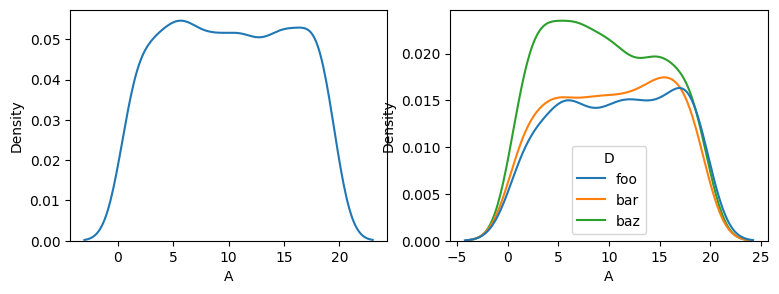

In [134]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
sns.kdeplot(data=df, x='A', ax = ax[0])
sns.kdeplot(data=df, x='A', hue='D', ax = ax[1])

Картина характерная для равномерного распределения.

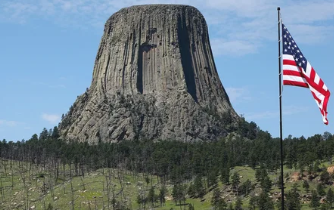

Заполним пропуски средним:

In [135]:
print(f'Mean by "A" column is {df.A.mean().round(2)}.')
df.A.fillna(df.A.mean().round(2), inplace=True)

Mean by "A" column is 10.08.


/tmp/ipython-input-2614772462.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.A.fillna(df.A.mean().round(2), inplace=True)


In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       1500 non-null   float64
 1   B       306 non-null    float64
 2   C       901 non-null    float64
 3   D       1500 non-null   object 
dtypes: float64(3), object(1)
memory usage: 47.0+ KB


Посмотрим на итоговое распределение:

<Axes: xlabel='A', ylabel='Density'>

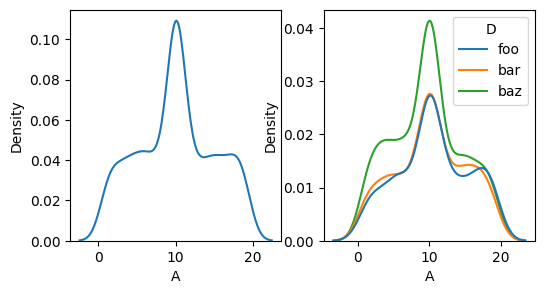

In [137]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
sns.kdeplot(data=df, x='A', ax = ax[0])
sns.kdeplot(data=df, x='A', hue='D', ax = ax[1])

Мы сломали распределение... Почему? Какой вывод можно сделать?

## Сделаем заполнение колонки `C`

Однако, сперва оценим распределение.

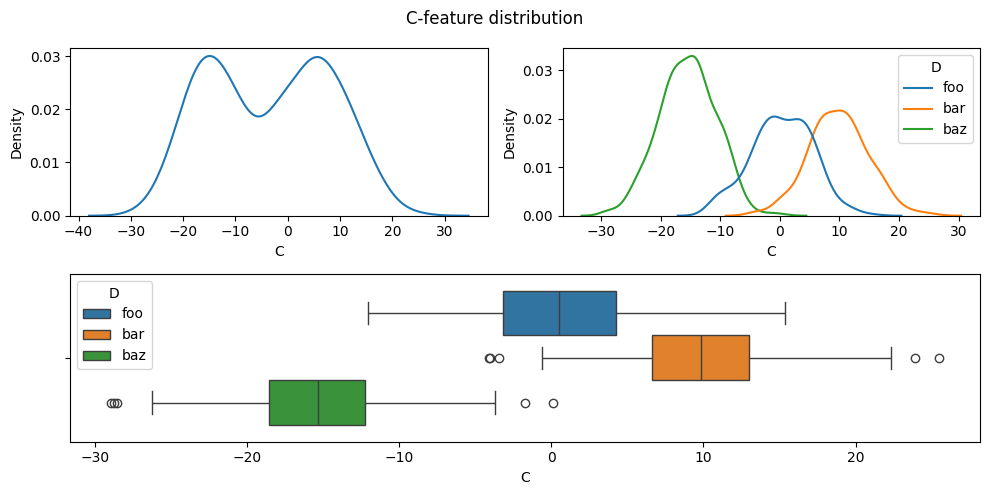

In [138]:
fig = plt.figure(figsize=(10, 5))
gs = fig.add_gridspec(2, 2)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

sns.kdeplot(data=df, x='C', ax=ax1)
sns.kdeplot(data=df, x='C', hue='D', ax=ax2)
sns.boxplot(data=df, x='C', hue='D', ax=ax3)

plt.suptitle('C-feature distribution')
plt.tight_layout()
plt.show()

Видим, что в этом признаке наблюдения явно зависят от значения группирующей переменной (фичи) `D`. Видится логичным заполнить средним не по всей колонке а средними по каждой группе. Получим эти средние:

In [139]:
mean_dict = {  label:df.loc[df.D == label, 'C'].mean().round(2).item() for label in df.D.unique() }
mean_dict

{'foo': 0.34, 'bar': 9.84, 'baz': -15.46}

Однако как эти значения "засунуть" в fillnа()?
Сформируем соразмерную датафрейму серию:

In [140]:
df.D.map(mean_dict).head()

,D
0,0.34
1,9.84
2,0.34
3,-15.46
4,9.84


In [141]:
df

,A,B,C,D
0,18.00,NaN,NaN,foo
1,17.00,NaN,NaN,bar
2,18.00,NaN,NaN,foo
3,14.00,NaN,NaN,baz
4,10.08,NaN,NaN,bar
...,...,...,...,...
1495,6.00,NaN,NaN,bar
1496,12.00,NaN,-4.830474,foo
1497,17.00,73.0,NaN,foo
1498,17.00,96.0,-10.176379,foo


Теперь мы для заполнения можем брать эту серию. Для каждого NaN будет подтянуто значение по соответствующему индексу из серии со средними значениями.

In [142]:
df.C.fillna(df.D.map(mean_dict), inplace=True)

/tmp/ipython-input-1007554084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.C.fillna(df.D.map(mean_dict), inplace=True)


Оценим результат:

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       1500 non-null   float64
 1   B       306 non-null    float64
 2   C       1500 non-null   float64
 3   D       1500 non-null   object 
dtypes: float64(3), object(1)
memory usage: 47.0+ KB


<Axes: xlabel='C', ylabel='Density'>

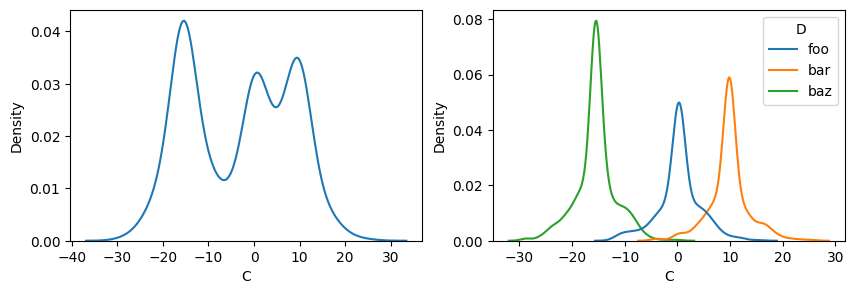

In [144]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
sns.kdeplot(data=df, x='C', ax = ax[0])
sns.kdeplot(data=df, x='C', hue='D', ax = ax[1])

Результат удовлетворительный. Однако колонку `B` мы так заполнять не будем. Почему?

## `dropna()`

Функция удаления строк или столбцов где есть пропуски. По дефолту она удалит строки, где есть хотя бы один пропуск. Если указать `axis=1`, то будут удалены столбцы, где есть хоть один пропуск. Чтобы не быть столь радикальными, рассмотрим параметры:

* `axis` = 0/1 - по строкам или столбцам
* `how`='all' - удалит только те строки (столбцы) где все значения пропущены
* `thresh` = 4 - порог. Указывает, сколько минимум должно быть непустых значений. Если непустых значений меньше, то строка (столбец) удаляется.
* `subset` = [...] - список колонок, с которыми работает функция.
* `inplace` - no comments)))

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       1500 non-null   float64
 1   B       306 non-null    float64
 2   C       1500 non-null   float64
 3   D       1500 non-null   object 
dtypes: float64(3), object(1)
memory usage: 47.0+ KB


У нас осталась одна колонка с пропусками. Давайте оценим степень ее заполненности.

In [146]:
part = (df.B.notnull().sum() / df.shape[0] * 100).round()
print(f'Колонка заполнена на {part} %.')

Колонка заполнена на 20.0 %.


Очень распространена практика, когда колонка, которая заполнена менее чем на 30% удаляется. Давайте удалим все колонки, которые заполнены менее чем на 30%: (с целью научиться писать код для общего случая)

In [147]:
min_num_val = int(round(df.shape[0]*.3))
min_num_val # столько должно быть минимум непустых значений в столбце для 30% порога

450

In [148]:
df.dropna(thresh=min_num_val, axis=1, inplace=True)

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       1500 non-null   float64
 1   C       1500 non-null   float64
 2   D       1500 non-null   object 
dtypes: float64(2), object(1)
memory usage: 35.3+ KB


Поработаем со строками. Сгенерим заново датасет.

In [150]:
df = get_data(1500)

In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       1197 non-null   object 
 1   B       321 non-null    float64
 2   C       895 non-null    float64
 3   D       1500 non-null   object 
dtypes: float64(2), object(2)
memory usage: 47.0+ KB


Посмотрим, сколько в каждой строке пропусков

In [152]:
df.isnull().sum(axis=1).describe()#[['mean', 'min', 'max']]

,0
count,1500.000000
mean,1.391333
std,0.758887
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,3.000000


Видим, что есть строки, где все три количественных значений пропущены. (Скорее всего так будет). Удалим те строки, где есть больше чем один пропуск. Тогда в строке должно остаться минимум 3 непустых значений.

In [153]:
df

,A,B,C,D
0,15,NaN,-11.138192,baz
1,16,NaN,2.758387,foo
2,NaN,31.0,7.177394,bar
3,4,NaN,7.520343,foo
4,16,23.0,-15.742813,baz
...,...,...,...,...
1495,4,99.0,NaN,baz
1496,8,NaN,NaN,bar
1497,10,NaN,NaN,foo
1498,10,NaN,-11.294751,baz


In [154]:
df.dropna(axis=0, thresh=3, inplace = True)

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 862 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       825 non-null    object 
 1   B       301 non-null    float64
 2   C       750 non-null    float64
 3   D       862 non-null    object 
dtypes: float64(2), object(2)
memory usage: 33.7+ KB


In [156]:
df.isnull().sum(axis=1).describe()[['mean', 'min', 'max']]

,0
mean,0.823666
min,0.000000
max,1.000000


## Вывод

Мы познакомились с некоторыми простейшими приемами работы с пропусками. Однако существуют более продвинутые подходы работы с ними. Мы всегда принимаем рашение, как заполнять или удалять пропуски, исходя из специфики данных. Мы обращаем внимание на распределение и на зависимость от других признаков. Нам нельзя нарушать существующие зависимости и также нежелательно просто удалять значения так как это приводит к потере ценных данных. Часто при заполнении пропусков прибегают, например, к предсказанию того, каково наиболее вероятно значение той ячейки, где имеется пропуск с точки зрения значений в других колонках. Для этого необходимо глубокое изучение данных, построение трендов, зависимостей итд...

## Duplicates

Давайте сформируем датафрейм с дупликатами и поработаем с ним.

In [157]:
df = get_data(1000)
df = pd.concat([df, df.sample(100)], axis=0) # выборка из 100 случайных строк и добавление ее в конец
df = df.sort_index().reset_index(drop=True) # приведение индексов в порядок
df

,A,B,C,D
0,10,NaN,-9.548640,baz
1,NaN,35.0,-9.962501,baz
2,NaN,35.0,-9.962501,baz
3,8,NaN,12.082711,bar
4,10,19.0,7.683357,bar
...,...,...,...,...
1095,16,NaN,-8.981918,foo
1096,NaN,96.0,13.804296,bar
1097,NaN,96.0,13.804296,bar
1098,17,11.0,NaN,bar


## `df.duplicated(col:str|list, keep='last'|'first'|False)`

Возвращает булевый массив, где `True` соответствует повтору.

* `keep` = 'first' - Первое появление элементов, которые ниже имеют дупликаты, не будет считаться дубликатом.
* `keep` = 'last' - Последнее появление элементов, которые выше имеют дупликаты, не будет считаться дубликатом.
* `keep` = False - для каждого элемента True пометит и сам элемент, который имеет повтор и все повторы.

In [158]:
df.duplicated(keep='first').sum() # столько строк, которые имеют повторы

np.int64(361)

In [159]:
df.duplicated('D')#.sum()

,0
0,False
1,True
2,True
3,False
4,True
...,...
1095,True
1096,True
1097,True
1098,True


In [160]:
test = pd.DataFrame([[np.nan for i in range (5)] for j in range (5)])
test

,0,1,2,3,4
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN


In [161]:
test.duplicated()

,0
0,False
1,True
2,True
3,True
4,True


In [162]:
new_arr = np.full((5, 5), np.nan)
df = pd.DataFrame(new_arr)
df.duplicated(keep = False)

,0
0,True
1,True
2,True
3,True
4,True


## `df.drop_duplicates(col:str|list, keep='last'|'first'|False, ...)`

In [163]:
df.shape

(5, 5)

In [164]:
df

,0,1,2,3,4
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN


In [165]:
df.drop_duplicates(inplace=True, ignore_index=True)

In [166]:
df.shape

(1, 5)

In [167]:
df

,0,1,2,3,4
0,NaN,NaN,NaN,NaN,NaN


# Practical part

In [222]:
#@title Create DataFrame
brend  = ['Kia', 'Hyundai']
model = ['Rio', 'Solaris']
mod_dict = {'Kia': 'Rio', 'Hyundai': 'Solaris'}
production_year = np.random.randint(2017, 2023, 400)
bin = np.random.randint(0, 2, 400)
br_col = [brend[i] for i in bin]
engine_type = [[1.4, 1.6][i] for i in bin]
engine_type = [[1.4, 1.6][i] for i in bin]
transmission = [['Auto', 'Manual'][i] for i in bin]

df = pd.DataFrame()
df['brend'] = br_col
df['model'] = df.brend.map(mod_dict)
df['production_year'] = production_year
df['mileage'] = df.production_year.map(lambda i: np.random.randint((2023-i)*10000, (2023-i)*50000, 1)[0].astype(str) + ' km')
df['engine_type'] = engine_type
df['transmission'] = transmission
df['USD_price'] = df.production_year.map(lambda i: np.random.randint(16000*(1 - (2023-i)*0.15), 15000*(1 - (2023-i)*0.05), 1)[0])
df.loc[df['engine_type']==1.4, 'USD_price'] *= 0.93
df.loc[df['transmission']=='Manual', 'USD_price'] *= 0.95
df.loc[df['transmission']=='Manual', 'USD_price'] *= 0.95
df['mileage_int'] = df.mileage.map(lambda i: int(i.replace(' km', '')))
df.loc[df['mileage_int'] > 100000, 'USD_price'] *= 0.88
df.loc[df['mileage_int'] > 150000, 'USD_price'] *= 0.92
df.loc[np.random.randint(0, 401, 5).tolist(), 'production_year'] = np.nan
df.loc[np.random.randint(0, 401, 5).tolist(), 'mileage'] = np.nan
df.drop('mileage_int', axis=1, inplace=True)
df = pd.concat([df, df.sample(100)], axis=0)
df = df.sort_index().reset_index(drop=True)

/tmp/ipython-input-3022915339.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[13222.74 10656.87  2084.13  7923.6  12761.46  9521.34  6316.56 12928.86
  2170.62  8493.69 12763.32 10270.92 12063.03  2821.62 13103.7  11332.05
  9907.29 12069.54 10417.86  7064.28 10875.42  5778.09 11556.18  7461.39
 12392.25 10393.68 10492.26  7470.69  7659.48  5177.31 11061.42 10209.54
  6871.77 12448.98 11386.92  9711.99  7577.64  9849.63 11840.76  7879.89
 10965.63 13099.05  7530.21  9656.19 11994.21  9217.23 11962.59 10706.16
 12186.72  9332.55  9752.91 12727.98 10841.94  7373.04  7892.91 12149.52
  5570.7   9764.07  4768.11 10602.93  7586.94 10742.43 12655.44  7803.63
 13081.38  7833.39  2314.77 12410.85  4153.38 11733.81  7460.46  8916.84
  7719.    3379.62 11287.41 13123.23  9219.09  8718.75  8466.72  4410.06
 11498.52  8832.21  8304.9   2353.83  6805.74 10732.2  11972.82  5766.
  9435.78  7074.51  4974.57  9586

In [223]:
df

,brend,model,production_year,mileage,engine_type,transmission,USD_price
0,Hyundai,Solaris,2020.0,70211 km,1.6,Manual,11461.750000
1,Hyundai,Solaris,2017.0,174453 km,1.6,Manual,3092.170048
2,Hyundai,Solaris,2022.0,24998 km,1.6,Manual,12858.820000
3,Hyundai,Solaris,2022.0,24998 km,1.6,Manual,12858.820000
4,Hyundai,Solaris,2019.0,71798 km,1.6,Manual,7758.792500
...,...,...,...,...,...,...,...
495,Hyundai,Solaris,2018.0,171803 km,1.6,Manual,4845.763648
496,Kia,Rio,2018.0,123337 km,1.4,Auto,4396.444800
497,Kia,Rio,2018.0,125247 km,1.4,Auto,7850.092800
498,Kia,Rio,2018.0,125247 km,1.4,Auto,7850.092800


In [224]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   brend            500 non-null    object 
 1   model            500 non-null    object 
 2   production_year  494 non-null    float64
 3   mileage          495 non-null    object 
 4   engine_type      500 non-null    float64
 5   transmission     500 non-null    object 
 6   USD_price        500 non-null    float64
dtypes: float64(3), object(4)
memory usage: 27.5+ KB


,production_year,engine_type,USD_price
count,494.000000,500.000000,500.000000
mean,2019.408907,1.507600,8472.839475
std,1.697989,0.099811,3132.754766
min,2017.000000,1.400000,1554.796320
25%,2018.000000,1.400000,5984.091696
50%,2019.000000,1.600000,8443.790000
75%,2021.000000,1.600000,11313.455625
max,2022.000000,1.600000,13222.740000


In [225]:
df.duplicated().sum()

np.int64(100)

In [226]:
df.isna().sum()

,0
brend,0
model,0
production_year,6
mileage,5
engine_type,0
transmission,0
USD_price,0


In [227]:
df['engine_type'].unique(), df['transmission'].unique()

(array([1.6, 1.4]), array(['Manual', 'Auto'], dtype=object))

In [228]:
df.loc[(df.engine_type == 1.4) & (df.transmission == 'Manual')]
df.loc[(df.engine_type == 1.6) & (df.transmission == 'Auto')]

,brend,model,production_year,mileage,engine_type,transmission,USD_price


## Task_1

Мы сгенерили датасет, посвященный продажам известных марок авто.

Давайте его изучим, посмотрим пропуски, типы данных в колонках и те колонки, которые можно сделать числовыми сделаем таковыми. Удалим дупликаты!!!

In [229]:
df.drop_duplicates(inplace=True)

In [230]:
df.loc[(df.production_year == np.nan) & (df.mileage == np.nan)]

,brend,model,production_year,mileage,engine_type,transmission,USD_price


In [231]:
df.dropna(thresh=5, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 0 to 499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   brend            400 non-null    object 
 1   model            400 non-null    object 
 2   production_year  395 non-null    float64
 3   mileage          395 non-null    object 
 4   engine_type      400 non-null    float64
 5   transmission     400 non-null    object 
 6   USD_price        400 non-null    float64
dtypes: float64(3), object(4)
memory usage: 25.0+ KB


## Task_2

Давайте проверим, есть ли тут строки, где встречается 2 раза NaN. Если такие строки есть, дропнeм их.

## Task_3

Давайте создадим колонку со средней стоимостью авто по годам выпуска.

И колонку со средним пробегом по годам выпуска.

Покажите на графике средние пробеги и средние стоимости по годам выпуска.

In [232]:
df.production_year.value_counts()

,count
production_year,
2019.0,81
2021.0,68
2018.0,67
2017.0,67
2022.0,60
2020.0,52


In [233]:
year_dict = {int(year.item()): df.loc[df.production_year == year, 'USD_price'].mean().item() for year in df.dropna().production_year.unique()}
year_dict

{2020: 9604.606642307692,
 2017: 4489.591814268658,
 2022: 12716.281416666667,
 2019: 7720.193464296296,
 2018: 6132.641633671642,
 2021: 11410.239044117645}

In [234]:
df['average_price'] = df.production_year.map(year_dict)

In [235]:
df.head()

,brend,model,production_year,mileage,engine_type,transmission,USD_price,average_price
0,Hyundai,Solaris,2020.0,70211 km,1.6,Manual,11461.750000,9604.606642
1,Hyundai,Solaris,2017.0,174453 km,1.6,Manual,3092.170048,4489.591814
2,Hyundai,Solaris,2022.0,24998 km,1.6,Manual,12858.820000,12716.281417
4,Hyundai,Solaris,2019.0,71798 km,1.6,Manual,7758.792500,7720.193464
5,Kia,Rio,2022.0,26767 km,1.4,Auto,13222.740000,12716.281417


In [236]:
df.mileage = df.mileage.str.replace(' km', '').astype(float)

In [237]:
mil_year = {int(year): df.loc[df.production_year == year, 'mileage'].mean().item() for year in df.dropna().production_year.unique()}
df['average_mile'] = df.production_year.map(mil_year)

<Axes: xlabel='production_year', ylabel='mileage'>

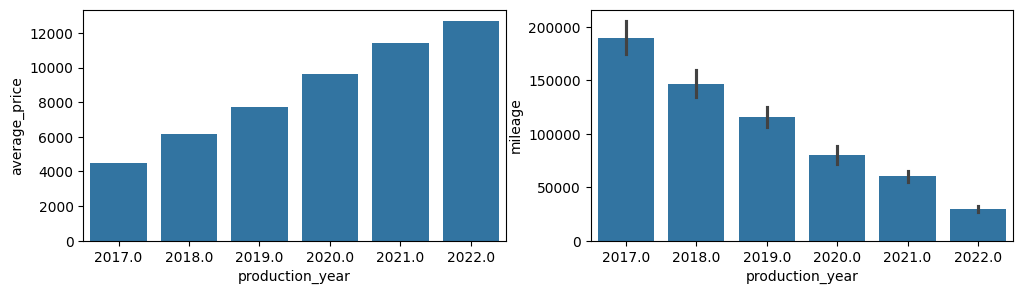

In [238]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
sns.barplot(data=df, y='average_price', x='production_year', ax=ax[0])
sns.barplot(data=df, y='mileage', x='production_year', ax=ax[1])


<Axes: xlabel='mileage', ylabel='USD_price'>

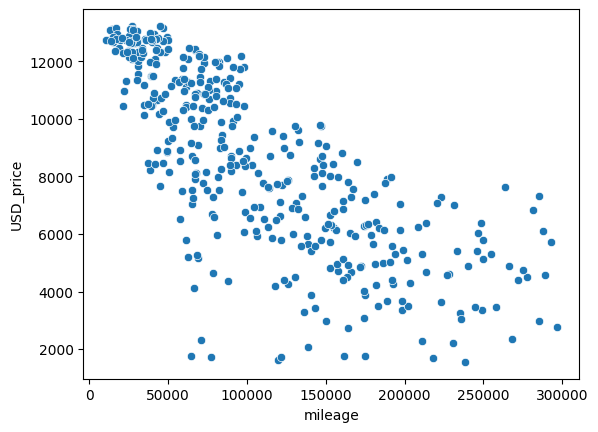

In [239]:
sns.scatterplot(x=df.mileage, y=df.USD_price)

In [240]:
k_price = -(df.USD_price - df.average_price)/df.average_price
m_pred = df.average_mile * (1 + k_price)

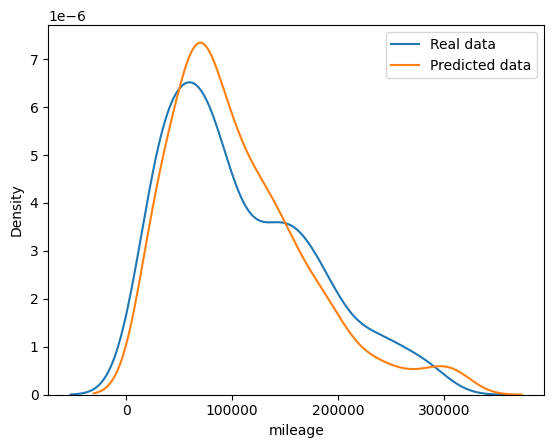

In [241]:
sns.kdeplot(df.mileage, label='Real data')
sns.kdeplot(m_pred, label='Predicted data')
plt.legend()

In [242]:
(abs((df.mileage - m_pred)/df.mileage).sum()) / df.shape[0]

np.float64(0.39495138075985353)

In [243]:
df.fillna({'mileage':m_pred}, inplace=True)

## Task_4

Наша задача по-умному заполнить пропуски в колонке "Пробег".. Если мы просто заполним средними то это может сломать зависимость между ценой и пробегом, а она по логике вещей существенна.

У нас есть средние пробега и и стоимости по годам. Нужно заполнить пропуски значением около среднего с учетом года выпуска но так, чтобы пробег был больше среднего, если цена ниже среднего и нгаоборот. Давайте подумаем, как это сделать...

In [244]:
k_price = -(df.USD_price - df.average_price)/df.average_price
p_pred = df.average_price * (1 - k_price)
k_mileage = (df.mileage - df.average_mile)/df.average_mile
m_pred = df.average_mile * (1 + k_mileage)

In [245]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   brend            400 non-null    object 
 1   model            400 non-null    object 
 2   production_year  395 non-null    float64
 3   mileage          400 non-null    float64
 4   engine_type      400 non-null    float64
 5   transmission     400 non-null    object 
 6   USD_price        400 non-null    float64
 7   average_price    395 non-null    float64
 8   average_mile     395 non-null    float64
dtypes: float64(6), object(3)
memory usage: 31.2+ KB


### Через Z-значение


```
year_dict = {int(year.item()): df.loc[df.production_year == year, 'USD_price'].mean().item() for year in df.dropna().production_year.unique()}
year_dict
```



## Task_5

У нас таже присутствуют пропуски в колонке Год выпуска.

Давайте также как-то по-умному их заполним!) Должно получиться)

In [246]:
df.production_year.unique()

array([2020., 2017., 2022., 2019., 2018., 2021.,   nan])

<Axes: xlabel='production_year', ylabel='USD_price'>

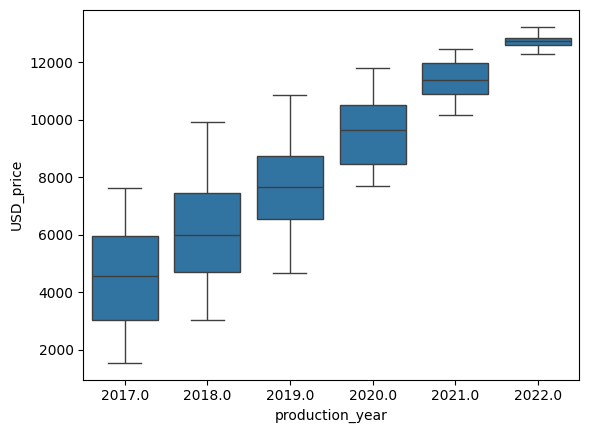

In [247]:
sns.boxplot(x = df.production_year, y = df.USD_price)

<Axes: xlabel='production_year', ylabel='mileage'>

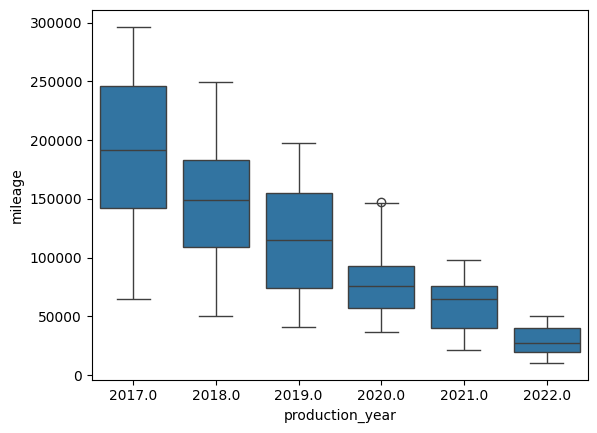

In [248]:
sns.boxplot(x = df.production_year, y = df.mileage)

In [249]:
df['alpha'] = df.USD_price/df.mileage

<Axes: xlabel='alpha', ylabel='production_year'>

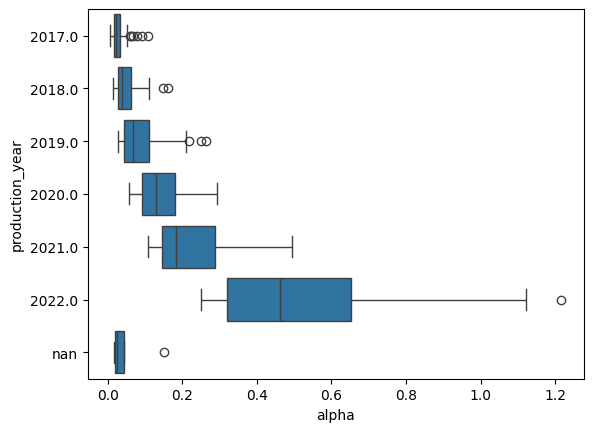

In [250]:
sns.boxplot(data=df.sort_values(by='production_year'), x='alpha', y=df.sort_values(by='production_year').production_year.astype(str))

In [251]:
year_d = {int(year.item()): df.loc[df.production_year == year, 'alpha'].mean().item() for year in sorted(df.production_year.dropna().unique())}
year_d

{2017: 0.028018714817435973,
 2018: 0.05046973916453701,
 2019: 0.08462878606739072,
 2020: 0.14041399379759356,
 2021: 0.225378215104416,
 2022: 0.5152906834608595}

In [252]:
df['mean_aplpha'] = df.production_year.map(year_d)
df

,brend,model,production_year,mileage,engine_type,transmission,USD_price,average_price,average_mile,alpha,mean_aplpha
0,Hyundai,Solaris,2020.0,70211.0,1.6,Manual,11461.750000,9604.606642,80467.461538,0.163247,0.140414
1,Hyundai,Solaris,2017.0,174453.0,1.6,Manual,3092.170048,4489.591814,190022.686567,0.017725,0.028019
2,Hyundai,Solaris,2022.0,24998.0,1.6,Manual,12858.820000,12716.281417,29365.203390,0.514394,0.515291
4,Hyundai,Solaris,2019.0,71798.0,1.6,Manual,7758.792500,7720.193464,115948.937500,0.108064,0.084629
5,Kia,Rio,2022.0,26767.0,1.4,Auto,13222.740000,12716.281417,29365.203390,0.493994,0.515291
...,...,...,...,...,...,...,...,...,...,...,...
494,Hyundai,Solaris,2019.0,79318.0,1.6,Manual,6574.712500,7720.193464,115948.937500,0.082891,0.084629
495,Hyundai,Solaris,2018.0,171803.0,1.6,Manual,4845.763648,6132.641634,146879.800000,0.028205,0.050470
496,Kia,Rio,2018.0,123337.0,1.4,Auto,4396.444800,6132.641634,146879.800000,0.035646,0.050470
497,Kia,Rio,2018.0,125247.0,1.4,Auto,7850.092800,6132.641634,146879.800000,0.062677,0.050470


In [253]:
sorted(df.production_year.dropna().unique())

[np.float64(2017.0),
 np.float64(2018.0),
 np.float64(2019.0),
 np.float64(2020.0),
 np.float64(2021.0),
 np.float64(2022.0)]

In [254]:
for year in sorted(df.production_year.dropna().unique()):
    year = int(year.item())
    df[f'{year}_avg_alpha'] = abs(df.alpha - year_d[year])

In [255]:
df.head()

,brend,model,production_year,mileage,engine_type,transmission,USD_price,average_price,average_mile,alpha,mean_aplpha,2017_avg_alpha,2018_avg_alpha,2019_avg_alpha,2020_avg_alpha,2021_avg_alpha,2022_avg_alpha
0,Hyundai,Solaris,2020.0,70211.0,1.6,Manual,11461.750000,9604.606642,80467.461538,0.163247,0.140414,0.135228,0.112777,0.078618,0.022833,0.062131,0.352043
1,Hyundai,Solaris,2017.0,174453.0,1.6,Manual,3092.170048,4489.591814,190022.686567,0.017725,0.028019,0.010294,0.032745,0.066904,0.122689,0.207653,0.497566
2,Hyundai,Solaris,2022.0,24998.0,1.6,Manual,12858.820000,12716.281417,29365.203390,0.514394,0.515291,0.486375,0.463924,0.429765,0.373980,0.289016,0.000897
4,Hyundai,Solaris,2019.0,71798.0,1.6,Manual,7758.792500,7720.193464,115948.937500,0.108064,0.084629,0.080045,0.057594,0.023435,0.032350,0.117314,0.407226
5,Kia,Rio,2022.0,26767.0,1.4,Auto,13222.740000,12716.281417,29365.203390,0.493994,0.515291,0.465975,0.443524,0.409365,0.353580,0.268616,0.021297


In [256]:
df['year_pred'] = df.iloc[:, -6:].idxmin(axis=1).str[:4].astype(int) #.replace('_avg_alpha', '').astype(int)

In [257]:
df.fillna({'production_year':df.year_pred}, inplace=True)

In [258]:
(df.production_year == df.year_pred).sum()/df.shape[0]

np.float64(0.4625)

In [259]:
df['name'] = df.brend + ' ' + df.model

In [260]:
df = df.reindex(columns=['name', 'USD_price', 'production_year', 'mileage', 'engine_type',
       'transmission'])

In [261]:
df.production_year = df.production_year.astype(int)
df.mileage = df.mileage.astype(int)
df.USD_price = round(df.USD_price, 2)

In [262]:
df.head()

,name,USD_price,production_year,mileage,engine_type,transmission
0,Hyundai Solaris,11461.75,2020,70211,1.6,Manual
1,Hyundai Solaris,3092.17,2017,174453,1.6,Manual
2,Hyundai Solaris,12858.82,2022,24998,1.6,Manual
4,Hyundai Solaris,7758.79,2019,71798,1.6,Manual
5,Kia Rio,13222.74,2022,26767,1.4,Auto


## Task_6

Давайте оценим, как в среднем много автомобиль проезжает за год независимо от типа двигателя и трансмиссии.

<Axes: xlabel='mileage', ylabel='USD_price'>

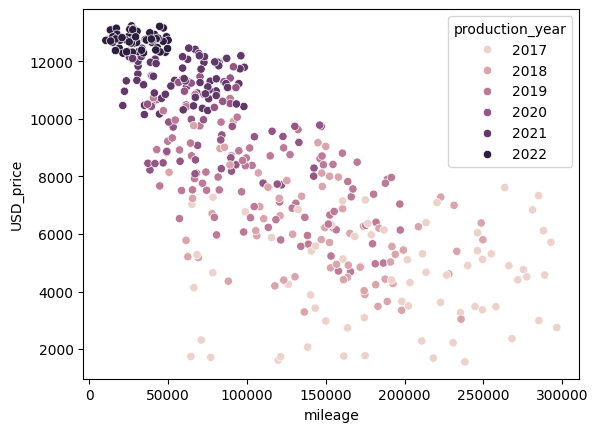

In [263]:
sns.scatterplot(x='mileage', y = 'USD_price', data = df, hue='production_year')

<Axes: xlabel='production_year', ylabel='USD_price'>

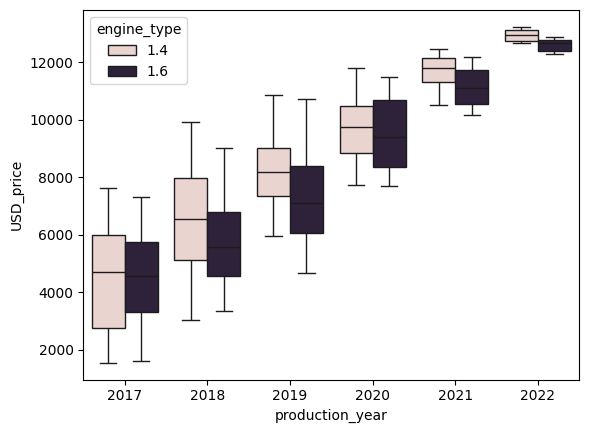

In [264]:
sns.boxplot(y = df.USD_price, x=df.production_year, hue = df.engine_type)